In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import platform
import h5py
# import beautifuljason as bjason

import numpy as np
import pandas as pd

from rdkit import Chem
import pandas as pd
from rdkit.Chem.rdMolDescriptors import CalcMolFormula

import simpleNMRjeolTools_v3 as sjt

from simpleNMRjeolTools_v3 import readJEOLmolecule, extractC13predictionsJEOL, create_c13predictions, jeolData

In [3]:
if platform.system() == 'Windows':
    fn = Path("C:\\Users\\vsmw51\\OneDrive - Durham University\\projects\\programming\\2025\\python\\awh\\bruker_data_sets\\apha_ionone_bruker_jeol\\exam_CMCse_1\\alpha_ionone.jjh5")
    # fn = Path(r"C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\bruker_data_sets\E72507_04164043_propyl_benzoate\04164043\04164043.jjh5")
elif platform.system() == 'Darwin':
    fn = Path("/opt/topspin4.5.0/examdata/exam_CMCse_1/alpha_ionone.jjh5")
    fn = Path("/Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/apha_ionone_bruker_jeol/exam_CMCse_1/alpha_ionone.jjh5")
    fn = Path("/Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043/04164043.jjh5")

else:
    print("Unsupported OS")


In [4]:
atoms_df = sjt.readJEOLmolecule(fn)
atoms_df

<KeysViewHDF5 ['0', '1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9']>


,El,NB.Conn,NB.Num,X,Y,nH,atom_idx,Z
0,6,[1],[1],8.343775,1.882732,3,0,0.0
1,6,"[1, 1]","[0, 2]",7.131377,1.182731,2,1,0.0
2,6,"[1, 1]","[1, 3]",5.918875,1.882732,2,2,0.0
3,8,"[1, 1]","[2, 4]",4.706477,1.182731,0,3,0.0
4,6,"[1, 2, 1]","[3, 5, 6]",3.493977,1.882732,0,4,0.0
5,8,[2],[4],3.493977,3.282732,0,5,0.0
6,6,"[1, 770, 769]","[4, 7, 11]",2.281574,1.182731,0,6,0.0
7,6,"[770, 769]","[6, 8]",1.069177,1.882732,1,7,0.0
8,6,"[769, 770]","[7, 9]",-0.143323,1.182731,1,8,0.0
9,6,"[770, 769]","[8, 10]",-0.143323,-0.217268,1,9,0.0


In [5]:
def extractC13predictionsJEOL(fn:Path, atoms_df:pd.DataFrame)->pd.DataFrame:

    c13shifts_df = pd.DataFrame(columns=['atom_idx',  'atomNumber', 'NumShifts', 'Shifts', 'CalcMethod'])

    with h5py.File(fn, 'r') as f:
        try:
            c13shifts = f['JasonDocument/Molecules/Molecules/0/NMRData/Spectra/SpectraList/0/Shifts']
            
            print('C13 Shifts\n\t', list(c13shifts))
            c13shifts_data = []
            for shift in c13shifts:
                print(shift)
                numC13shifts = len(c13shifts[shift].attrs.get('Value', None))
                calcMethods = c13shifts[shift].attrs.get('Value.Method', None)
                # print(f"  {int(shift)+1}, \t{numC13shifts},\t{int(c13shifts[shift].attrs.get('Nums', None)[0])+1}:\t{c13shifts[shift].attrs.get('Value', None)}\t{calcMethods}")
                # add row to dataframe
                c13_row = {
                    'atom_idx': int(c13shifts[shift].attrs.get('Nums', None)[0]),
                    'atomNumber': int(c13shifts[shift].attrs.get('Nums', None)[0])+1,
                    'NumShifts': numC13shifts,
                    'Shifts': c13shifts[shift].attrs.get('Value', None),
                    'CalcMethod': calcMethods
                }
                c13shifts_data.append(c13_row)

            print("C13 Shifts DataFrame:\n", c13shifts_df.shape)
            
            c13shifts_df = pd.DataFrame(c13shifts_data)
            c13shifts_df["numProtons"] = 0  # Initialize numProtons column
            print("C13shifts_df.columns:", c13shifts_df.columns)
            # print shape of dataframe
            print("C13 Shifts DataFrame:\n", c13shifts_df.shape)

            for row in atoms_df.itertuples():
                atom_idx = row.atom_idx
                numProtons = int(row.nH)
                # replace numProtons in c13shifts_df using atom_idx

                idx = c13shifts_df.index[c13shifts_df['atom_idx'] == atom_idx].tolist()
                print(idx, atom_idx, numProtons)
                if idx:
                    c13shifts_df.loc[idx, "numProtons"] = numProtons
            #  convert numProtons to integer
            c13shifts_df["numProtons"] = c13shifts_df["numProtons"].astype(int)
        except KeyError as e:
            print(f"KeyError: {e}")

    return c13shifts_df

In [6]:
# change type of atom_idx to int in atoms_df
atoms_df['atom_idx'] = atoms_df['atom_idx'].astype(int)

In [7]:
c13_predictions_df = extractC13predictionsJEOL(fn, atoms_df)

C13 Shifts
	 ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
0
1
2
3
4
5
6
7
8
9
C13 Shifts DataFrame:
 (0, 5)
C13shifts_df.columns: Index(['atom_idx', 'atomNumber', 'NumShifts', 'Shifts', 'CalcMethod',
       'numProtons'],
      dtype='object')
C13 Shifts DataFrame:
 (10, 6)
[0] 0 3
[1] 1 2
[2] 2 2
[] 3 0
[3] 4 0
[] 5 0
[5] 6 0
[6] 7 1
[8] 8 1
[4] 9 1
[9] 10 1
[7] 11 1


In [8]:
c13_predictions_df

,atom_idx,atomNumber,NumShifts,Shifts,CalcMethod,numProtons
0,0,1,4,"[10.532712, 10.989144, 10.463333, 10.463333]","[1, 2, 4, 5]",3
1,1,2,4,"[22.12875, 21.947124, 22.14, 22.14]","[1, 2, 4, 5]",2
2,2,3,4,"[66.526596, 66.84713, 66.513336, 66.513336]","[1, 2, 4, 5]",2
3,4,5,4,"[166.66202, 166.92209, -1000000.0, 166.92209]","[1, 2, 4, 5]",0
4,9,10,4,"[132.77606, 132.96042, 133.57062, 133.57062]","[1, 2, 4, 5]",1
5,6,7,4,"[130.51947, 130.18306, -1000000.0, 130.18306]","[1, 2, 4, 5]",0
6,7,8,4,"[129.51721, 129.77034, 129.60924, 129.60924]","[1, 2, 4, 5]",1
7,11,12,4,"[129.51721, 129.77034, 129.60924, 129.60924]","[1, 2, 4, 5]",1
8,8,9,4,"[128.30045, 128.63037, 128.41615, 128.41615]","[1, 2, 4, 5]",1
9,10,11,4,"[128.30045, 128.63037, 128.41615, 128.41615]","[1, 2, 4, 5]",1


In [9]:
atoms_df.atom_idx

0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
11    11
Name: atom_idx, dtype: int64

In [10]:
c13_predictions_df.atom_idx

0     0
1     1
2     2
3     4
4     9
5     6
6     7
7    11
8     8
9    10
Name: atom_idx, dtype: int64

In [12]:
# local_remote = "http://127.0.0.1:5000"
# local_remote = "https://test-simplenmr.pythonanywhere.com"
local_remote = "https://simplenmr.pythonanywhere.com"

# At the start of your main program
# app = init_qt_app()

print("SERVER ADDRESS:", local_remote)

ml_address = f"{local_remote}/check_machine_learning"

simpleNMR_address = f"{local_remote}/simpleMNOVA"

SERVER ADDRESS: https://simplenmr.pythonanywhere.com


In [13]:
jeol_data = jeolData(fn)

Creating working directory for: /Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043/04164043.jjh5
Working directory is: /Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043
Working directory with forward slashes: /Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043
8 peaks found in 0
6 peaks found in 1
No peaks found in 2
2 peaks found in 3
<KeysViewHDF5 ['0', '1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9']>
{'datatype': 'carbonAtomsInfo', 'count': 10, 'data': {'0': {'atom_idx': 0, 'id': 0, 'atomNumber': 1, 'symbol': 'C', 'numProtons': 3}, '1': {'atom_idx': 1, 'id': 1, 'atomNumber': 2, 'symbol': 'C', 'numProtons': 2}, '2': {'atom_idx': 2, 'id': 2, 'atomNumber': 3, 'symbol': 'C', 'numProtons': 2}, '4': {'atom_idx': 4, 'id': 4,

In [13]:
dir(jeol_data)

['MNOVAcalcMethod',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'allatomsInfo',
 'analysis_cancelled',
 'append_specdata',
 'atoms_df',
 'c13_predictions_df',
 'c13predictions',
 'carbonCalcPositionsMethod',
 'carbonatomsInfo',
 'choosePeakPickedSpectaforSimpleNMR',
 'createJsonDict',
 'datasets_with_peaks',
 'file_path',
 'hostname',
 'molfile',
 'molstr',
 'rdkit_mol',
 'smiles',
 'smiles_str',
 'spectra_assignments',
 'updateDatawithExptNames',
 'workingDirectory',
 'workingFilename']

In [20]:
jeol_data.datasets_with_peaks.keys()

dict_keys(['0', '1', '3'])

In [21]:
jeol_data.chosenSpectra

AttributeError: 'jeolData' object has no attribute 'chosenSpectra'

In [15]:
jeol_data.datasets_with_peaks['0'].keys()

dict_keys(['spec_info', 'peaks', 'integrals', 'multiplets'])

In [16]:
jeol_data.datasets_with_peaks['3']['spec_info']

{'pulsesequence': 'hmbcetgpl3nd.ptg',
 'experimenttype': 'HMBC',
 'datafilename': '/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043/16/pdata/1',
 'solvent': '',
 'expt_fn': '1',
 'specfrequency': [np.float64(699.74), np.float64(175.949762948)],
 'type': '2D',
 'temperature': None,
 'nucleus': ['1H', '13C']}

In [17]:
jeol_data.datasets_with_peaks['3']['peaks']

{'data': {'0': {'intensity': np.float64(18909127.0),
   'delta2': np.float64(8.077107885344784),
   'delta1': np.float64(166.70699997816473),
   'annotation': '',
   'type': 0},
  '1': {'intensity': np.float64(75919091.0),
   'delta2': np.float64(4.308690020002221),
   'delta1': np.float64(166.70562743562132),
   'annotation': '',
   'type': 0}},
 'count': 2,
 'datatype': 'peaks'}

In [18]:
def dataframe_to_rdkit_molecule(df):
    """
    Convert a pandas DataFrame with molecular structure data directly to RDKit molecule
    
    Args:
        df: DataFrame with columns ['El', 'NB.Conn', 'NB.Num', 'X', 'Y', 'nH', 'Z']
    
    Returns:
        rdkit.Chem.Mol: RDKit molecule object or None if creation failed
    """
    
    try:
        # Create an editable molecule object
        mol = Chem.EditableMol(Chem.Mol())
        
        # Reset index to ensure proper atom numbering
        mol_df = df.copy().reset_index(drop=True)
        
        # Handle missing Z coordinates
        if 'Z' not in mol_df.columns:
            mol_df['Z'] = 0.0
        mol_df['Z'] = mol_df['Z'].fillna(0.0)
        
        print(f"Adding {len(mol_df)} atoms to molecule...")
        
        # Step 1: Add all atoms
        atom_indices = {}
        for idx, row in mol_df.iterrows():
            element_num = int(row['El'])
            
            # Create atom with the correct element
            atom = Chem.Atom(element_num)
            
            # Add atom to molecule
            atom_idx = mol.AddAtom(atom)
            atom_indices[idx] = atom_idx
            
            element_symbol = atom.GetSymbol()
            print(f"   Added atom {idx}: {element_symbol} (atomic #{element_num}) at RDKit index {atom_idx}")
        
        print(f"\nAdding bonds...")
        
        # Step 2: Add bonds based on connectivity
        bonds_added = set()  # Track bonds to avoid duplicates
        bond_count = 0
        
        for idx, row in mol_df.iterrows():
            rdkit_atom_idx = atom_indices[idx]
            
            # Get connection data
            nb_num = row.get('NB.Num')
            nb_conn = row.get('NB.Conn')
            
            # Check if connection data exists
            nb_num_valid = nb_num is not None and not (isinstance(nb_num, float) and pd.isna(nb_num))
            nb_conn_valid = nb_conn is not None and not (isinstance(nb_conn, float) and pd.isna(nb_conn))
            
            if nb_num_valid and nb_conn_valid:
                try:
                    # Handle numpy arrays and ensure we have lists
                    if isinstance(nb_num, np.ndarray):
                        nb_num = nb_num.tolist()
                    elif not isinstance(nb_num, list):
                        nb_num = [nb_num]
                        
                    if isinstance(nb_conn, np.ndarray):
                        nb_conn = nb_conn.tolist()
                    elif not isinstance(nb_conn, list):
                        nb_conn = [nb_conn]
                    
                    # Process each connection
                    for i, connected_atom in enumerate(nb_num):
                        if (connected_atom is not None and 
                            not (isinstance(connected_atom, float) and pd.isna(connected_atom)) and 
                            connected_atom != ''):
                            
                            try:
                                connected_df_idx = int(float(connected_atom))
                                
                                # Skip self-connections
                                if connected_df_idx == idx:
                                    continue
                                
                                # Check if connected atom exists in our dataframe
                                if connected_df_idx not in atom_indices:
                                    print(f"   Warning: Connected atom {connected_df_idx} not found in dataframe")
                                    continue
                                
                                connected_rdkit_idx = atom_indices[connected_df_idx]
                                
                                # Avoid duplicate bonds
                                bond_pair = tuple(sorted([rdkit_atom_idx, connected_rdkit_idx]))
                                if bond_pair not in bonds_added:
                                    
                                    # Get bond order
                                    if i < len(nb_conn):
                                        bond_order = nb_conn[i]
                                    else:
                                        bond_order = 1
                                    
                                    # Convert bond order to RDKit bond type
                                    if bond_order == 1:
                                        rdkit_bond_type = Chem.BondType.SINGLE
                                        bond_name = "SINGLE"
                                    elif bond_order == 2:
                                        rdkit_bond_type = Chem.BondType.DOUBLE
                                        bond_name = "DOUBLE"
                                    elif bond_order == 3:
                                        rdkit_bond_type = Chem.BondType.TRIPLE
                                        bond_name = "TRIPLE"
                                    elif bond_order in (770, 769):  # Aromatic
                                        rdkit_bond_type = Chem.BondType.AROMATIC
                                        bond_name = "AROMATIC"
                                    elif bond_order == 514:  # Double bond
                                        rdkit_bond_type = Chem.BondType.DOUBLE
                                        bond_name = "DOUBLE (from 514)"
                                    else:
                                        # Default to single bond for unknown types
                                        rdkit_bond_type = Chem.BondType.SINGLE
                                        bond_name = f"SINGLE (from unknown {bond_order})"
                                    
                                    # Add the bond
                                    mol.AddBond(rdkit_atom_idx, connected_rdkit_idx, rdkit_bond_type)
                                    bonds_added.add(bond_pair)
                                    bond_count += 1
                                    
                                    print(f"   Added bond {bond_count}: Atom{idx}({rdkit_atom_idx}) - Atom{connected_df_idx}({connected_rdkit_idx}) [{bond_name}]")
                                    
                            except (ValueError, TypeError) as e:
                                print(f"   Warning: Could not parse connection {connected_atom} for atom {idx}: {e}")
                                continue
                                
                except Exception as e:
                    print(f"   Warning: Error processing connections for atom {idx}: {e}")
                    continue
        
        print(f"\nTotal bonds added: {bond_count}")
        
        # Step 3: Convert to final molecule and add 2D coordinates
        final_mol = mol.GetMol()
        
        # Add 2D coordinates (ignoring Z since it's typically 0 for 2D molecules)
        if all(col in mol_df.columns for col in ['X', 'Y']):
            print("Adding 2D coordinates...")
            conf = Chem.Conformer(len(mol_df))
            conf.Set3D(False)  # Mark this as a 2D conformer
            
            for idx, row in mol_df.iterrows():
                rdkit_idx = atom_indices[idx]
                x, y = float(row['X']), float(row['Y'])
                # For 2D molecules, set Z to 0
                conf.SetAtomPosition(rdkit_idx, (x, y, 0.0))
            
            final_mol.AddConformer(conf)
            print("2D coordinates added successfully")
        else:
            print("X and/or Y coordinates not found - molecule will have no coordinates")
        
        # Step 4: Sanitize the molecule
        print("\nSanitizing molecule...")
        try:
            Chem.SanitizeMol(final_mol)
            print("Molecule sanitized successfully!")
            return final_mol
            
        except Exception as sanitize_error:
            print(f"Sanitization failed: {sanitize_error}")
            print("Trying with less strict sanitization...")
            
            # Try sanitization with specific operations
            try:
                sanitize_ops = (Chem.SanitizeFlags.SANITIZE_FINDRADICALS |
                               Chem.SanitizeFlags.SANITIZE_KEKULIZE |
                               Chem.SanitizeFlags.SANITIZE_SETAROMATICITY |
                               Chem.SanitizeFlags.SANITIZE_SETCONJUGATION |
                               Chem.SanitizeFlags.SANITIZE_SETHYBRIDIZATION |
                               Chem.SanitizeFlags.SANITIZE_CLEANUPCHIRALITY)
                
                Chem.SanitizeMol(final_mol, sanitizeOps=sanitize_ops)
                print("Molecule sanitized with custom operations!")
                return final_mol

            except Exception as e2:
                print(f"Custom sanitization also failed: {e2}")
                print("Returning unsanitized molecule...")
                return final_mol

    except Exception as e:
        print(f"Error creating molecule: {e}")
        return None

def fix_stereo_info(molstr):
    lines = molstr.splitlines()
    for i, line in enumerate(lines):
        words = line.split()
        # Check if the line has 4 columns then we have reached the connectivity group
        if len(words) == 4:
            # If the last column is not '0', we have stereo info to fix
            if words[-1] != '0':
                print(f"Fixing stereo info in line {i}: {line}")
                # Fix the stereo info by replacing it with '0'
                if len(words[-1]) == 1:
                    line = line[:-1] + '0'
                elif len(words[-1]) == 2:
                    line = line[:-2] + '00'
                else:
                    print("Unexpected length:", len(words[-1]))
                # update the line in the original list
                lines[i] = line

    return "\n".join(lines)

Adding 12 atoms to molecule...
   Added atom 0: C (atomic #6) at RDKit index 0
   Added atom 1: C (atomic #6) at RDKit index 1
   Added atom 2: C (atomic #6) at RDKit index 2
   Added atom 3: O (atomic #8) at RDKit index 3
   Added atom 4: C (atomic #6) at RDKit index 4
   Added atom 5: O (atomic #8) at RDKit index 5
   Added atom 6: C (atomic #6) at RDKit index 6
   Added atom 7: C (atomic #6) at RDKit index 7
   Added atom 8: C (atomic #6) at RDKit index 8
   Added atom 9: C (atomic #6) at RDKit index 9
   Added atom 10: C (atomic #6) at RDKit index 10
   Added atom 11: C (atomic #6) at RDKit index 11

Adding bonds...
   Added bond 1: Atom0(0) - Atom1(1) [SINGLE]
   Added bond 2: Atom1(1) - Atom2(2) [SINGLE]
   Added bond 3: Atom2(2) - Atom3(3) [SINGLE]
   Added bond 4: Atom3(3) - Atom4(4) [SINGLE]
   Added bond 5: Atom4(4) - Atom5(5) [DOUBLE]
   Added bond 6: Atom4(4) - Atom6(6) [SINGLE]
   Added bond 7: Atom6(6) - Atom7(7) [AROMATIC]
   Added bond 8: Atom6(6) - Atom11(11) [AROMATIC

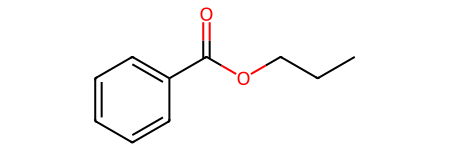

In [19]:
dataframe_to_rdkit_molecule(atoms_df)

In [20]:
atoms_df

,El,NB.Conn,NB.Num,X,Y,nH,atom_idx,Z
0,6,[1],[1],8.343775,1.882732,3,0,0.0
1,6,"[1, 1]","[0, 2]",7.131377,1.182731,2,1,0.0
2,6,"[1, 1]","[1, 3]",5.918875,1.882732,2,2,0.0
3,8,"[1, 1]","[2, 4]",4.706477,1.182731,0,3,0.0
4,6,"[1, 2, 1]","[3, 5, 6]",3.493977,1.882732,0,4,0.0
5,8,[2],[4],3.493977,3.282732,0,5,0.0
6,6,"[1, 770, 769]","[4, 7, 11]",2.281574,1.182731,0,6,0.0
7,6,"[770, 769]","[6, 8]",1.069177,1.882732,1,7,0.0
8,6,"[769, 770]","[7, 9]",-0.143323,1.182731,1,8,0.0
9,6,"[770, 769]","[8, 10]",-0.143323,-0.217268,1,9,0.0


In [18]:
# reorder atoms_df based on atom_idx
atoms_df_ordered = atoms_df.sort_values(by='atom_idx').reset_index(drop=True)
atoms_df_ordered

,El,NB.Conn,NB.Num,X,Y,nH,atom_idx,Z
0,6,"[1, 1, 2]","[9, 2, 13]",4.754556,0.182120,0,0,0.0
1,6,"[1, 2]","[5, 2]",2.156452,0.182120,1,1,0.0
2,6,"[2, 1]","[1, 0]",3.455554,0.932125,1,2,0.0
3,6,"[1, 513, 514]","[12, 5, 4]",0.857451,2.432119,0,3,0.0
4,6,"[514, 513]","[3, 11]",-0.441555,3.182124,1,4,0.0
5,6,"[513, 1, 513]","[6, 1, 3]",0.857451,0.932125,1,5,0.0
6,6,"[1, 1, 513, 513]","[10, 8, 7, 5]",-0.441555,0.182120,0,6,0.0
7,6,"[513, 513]","[6, 11]",-1.740650,0.932125,2,7,0.0
8,6,[1],[6],0.522561,-0.966971,3,8,0.0
9,6,[1],[0],6.053656,0.932125,3,9,0.0


Adding 14 atoms to molecule...
   Added atom 0: C (atomic #6) at RDKit index 0
   Added atom 1: C (atomic #6) at RDKit index 1
   Added atom 2: C (atomic #6) at RDKit index 2
   Added atom 3: C (atomic #6) at RDKit index 3
   Added atom 4: C (atomic #6) at RDKit index 4
   Added atom 5: C (atomic #6) at RDKit index 5
   Added atom 6: C (atomic #6) at RDKit index 6
   Added atom 7: C (atomic #6) at RDKit index 7
   Added atom 8: C (atomic #6) at RDKit index 8
   Added atom 9: C (atomic #6) at RDKit index 9
   Added atom 10: C (atomic #6) at RDKit index 10
   Added atom 11: C (atomic #6) at RDKit index 11
   Added atom 12: C (atomic #6) at RDKit index 12
   Added atom 13: O (atomic #8) at RDKit index 13

Adding bonds...
   Added bond 1: Atom0(0) - Atom9(9) [SINGLE]
   Added bond 2: Atom0(0) - Atom2(2) [SINGLE]
   Added bond 3: Atom0(0) - Atom13(13) [DOUBLE]
   Added bond 4: Atom1(1) - Atom5(5) [SINGLE]
   Added bond 5: Atom1(1) - Atom2(2) [DOUBLE]
   Added bond 6: Atom3(3) - Atom12(12) [

[13:26:34] Can't kekulize mol.  Unkekulized atoms: 4 5 7 11


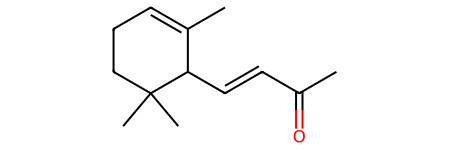

In [19]:
dataframe_to_rdkit_molecule(atoms_df_ordered)